In [1]:
import numpy as np
from scipy.special import comb
import time
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
def optimal_N(L):
    """N that maximizes the full sector dimension C(L,N)*2^N."""
    dims = {N: comb(L, N) * (2**N) for N in range(1, L)}
    return max(dims, key=dims.get)

def optimal_Na(N):
    dims = {Na: comb(N, Na) for Na in range(1, N + 1)}
    return max(dims, key = dims.get)

In [3]:
def random_config(L, N, Na, rng=None):
    """
    Returns a random configuration of length L with exactly N particles,
    Na of which are flavor a (|a>=0) and N-Na are flavor b (|b>=2).
    The remaining L-N sites are |vac> (1).
    """
    if rng is None:
        rng = np.random.default_rng()
    config = np.ones(L, dtype=int)
    particle_sites = rng.choice(L, size=N, replace=False)
    flavors = np.array([0] * Na + [2] * (N - Na))
    rng.shuffle(flavors)
    config[particle_sites] = flavors
    return config.tolist()

In [4]:
for L_test in range(4, 51):
    N_opt  = optimal_N(L_test)
    Na_opt = optimal_Na(N_opt)
    dim    = comb(L_test, N_opt) * comb(N_opt, Na_opt)
    print(f"L = {L_test:2d} →  N={N_opt}, Na = {Na_opt}  dim={dim} ")

L =  4 →  N=3, Na = 1  dim=12.0 
L =  5 →  N=3, Na = 1  dim=30.0 
L =  6 →  N=4, Na = 2  dim=90.0 
L =  7 →  N=5, Na = 2  dim=210.0 
L =  8 →  N=5, Na = 2  dim=560.0 
L =  9 →  N=6, Na = 3  dim=1680.0 
L = 10 →  N=7, Na = 3  dim=4200.0 
L = 11 →  N=7, Na = 3  dim=11550.0 
L = 12 →  N=8, Na = 4  dim=34650.0 
L = 13 →  N=9, Na = 4  dim=90090.0 
L = 14 →  N=9, Na = 4  dim=252252.0 
L = 15 →  N=10, Na = 5  dim=756756.0 
L = 16 →  N=11, Na = 5  dim=2018016.0 
L = 17 →  N=11, Na = 5  dim=5717712.0 
L = 18 →  N=12, Na = 6  dim=17153136.0 
L = 19 →  N=13, Na = 6  dim=46558512.0 
L = 20 →  N=13, Na = 6  dim=133024320.0 
L = 21 →  N=14, Na = 7  dim=399072960.0 
L = 22 →  N=15, Na = 7  dim=1097450640.0 
L = 23 →  N=15, Na = 7  dim=3155170590.0 
L = 24 →  N=16, Na = 8  dim=9465511770.0 
L = 25 →  N=17, Na = 8  dim=26293088250.0 
L = 26 →  N=17, Na = 8  dim=75957810500.0 
L = 27 →  N=18, Na = 9  dim=227873431500.0 
L = 28 →  N=19, Na = 9  dim=638045608200.0 
L = 29 →  N=19, Na = 9  dim=185033226378

In [5]:
L = 20
for N in range(1, L):
    print(N, optimal_Na(N))

1 1
2 1
3 1
4 2
5 2
6 3
7 3
8 4
9 4
10 5
11 5
12 6
13 6
14 7
15 7
16 8
17 8
18 9
19 9


In [6]:
L = 10
N = 7
Na = 3

In [7]:
config = random_config(L, N, Na)
print(config)

[1, 0, 1, 2, 2, 2, 0, 1, 2, 0]


In [8]:
state_labels = ["Vac"] * len(config)
print(state_labels)

for i in range(len(config)):
    if config[i] == 0:
        state_labels[i] = "A"
    elif config[i] == 2:
        state_labels[i] = "B"

print(state_labels)

['Vac', 'Vac', 'Vac', 'Vac', 'Vac', 'Vac', 'Vac', 'Vac', 'Vac', 'Vac']
['Vac', 'A', 'Vac', 'B', 'B', 'B', 'A', 'Vac', 'B', 'A']


In [9]:
df8   = pd.read_csv("results/bond_convergence/n_profile_vs_t_L10_chi8.csv",   comment="#")
df16  = pd.read_csv("results/bond_convergence/n_profile_vs_t_L10_chi16.csv",  comment="#")
df32  = pd.read_csv("results/bond_convergence/n_profile_vs_t_L10_chi32.csv",  comment="#")
df256 = pd.read_csv("results/bond_convergence/n_profile_vs_t_L10_chi256.csv", comment="#")

In [10]:
with open("results/bond_convergence/n_profile_vs_t_L10_chi256.csv") as f:
    first_line = f.readline()
E0 = float(first_line.strip().split("=")[1])
print(E0)

-0.4491053157526397


In [11]:
df8.keys()

Index(['time', 'energy', 'S_mid', 'trunc_err', 'n_1', 'n_2', 'n_3', 'n_4',
       'n_5', 'n_6', 'n_7', 'n_8', 'n_9', 'n_10'],
      dtype='str')

In [12]:
df256.keys()

Index(['time', 'energy', 'S_mid', 'trunc_err', 'n_1', 'n_2', 'n_3', 'n_4',
       'n_5', 'n_6', 'n_7', 'n_8', 'n_9', 'n_10'],
      dtype='str')

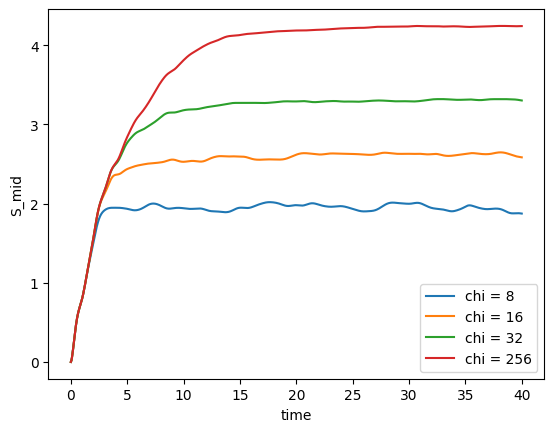

In [13]:
plt.figure()
plt.plot(df8['time'],   df8['S_mid'],   label="chi = 8")
plt.plot(df16['time'],  df16['S_mid'],  label="chi = 16")
plt.plot(df32['time'],  df32['S_mid'],  label="chi = 32")
plt.plot(df256['time'], df256['S_mid'], label="chi = 256")
plt.xlabel("time")
plt.ylabel("S_mid")
plt.legend()
plt.show()

In [14]:
3**5

243

In [15]:
128*2

256